In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("Data_Bayes.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape :", df.shape)

print("\nColumns :")
print(df.columns)

print("\nData Types :")
print(df.dtypes)

print("\nMissing Values :")
print(df.isnull().sum())

DATASET INFORMATION

Shape : (569, 33)

Columns :
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Data Types :
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean          

In [4]:
# Drop unnecessary columns

df.drop(columns=["id", "Unnamed: 32"], inplace=True)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print(df["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


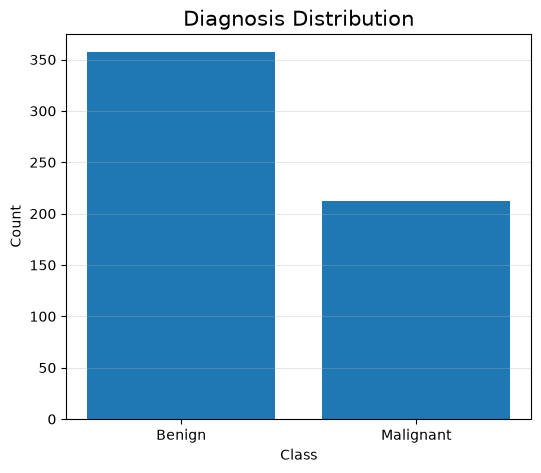

In [7]:
counts = df["diagnosis"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Benign","Malignant"],
    [counts[0],counts[1]]
)

plt.title("Diagnosis Distribution",fontsize=15)

plt.xlabel("Class")

plt.ylabel("Count")

plt.grid(axis="y",alpha=0.3)

plt.show()

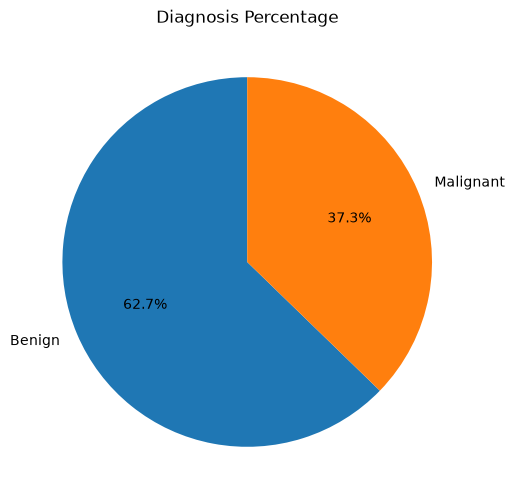

In [8]:
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Benign","Malignant"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Diagnosis Percentage")

plt.show()

In [9]:
X = df.drop(columns="diagnosis")

y = df["diagnosis"]

print("Features Shape :",X.shape)

print("Target Shape :",y.shape)

Features Shape : (569, 30)
Target Shape : (569,)


In [10]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [11]:
dt = DecisionTreeClassifier(

    criterion="gini",

    random_state=42

)

In [12]:
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [13]:
y_pred = dt.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test,y_pred)

print("="*50)

print("Decision Tree Accuracy : {:.2f}%".format(accuracy*100))

print("="*50)

Decision Tree Accuracy : 92.98%


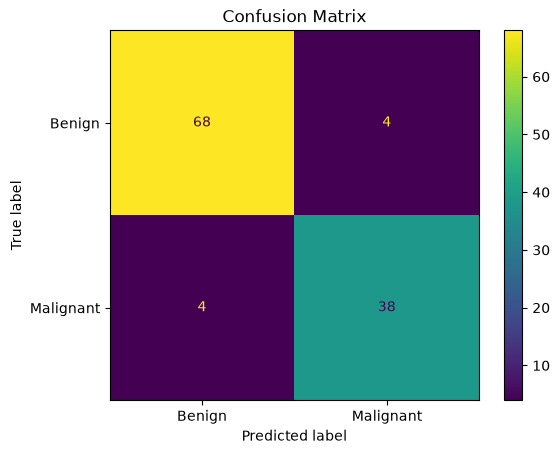

In [15]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Benign","Malignant"]

)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [16]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [17]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":dt.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
22,perimeter_worst,0.727477
27,concave points_worst,0.078970
24,smoothness_worst,0.040833
1,texture_mean,0.037871
21,texture_worst,0.022545
3,area_mean,0.022452
20,radius_worst,0.017530
23,area_worst,0.015606
7,concave points_mean,0.013416
16,concavity_se,0.007043


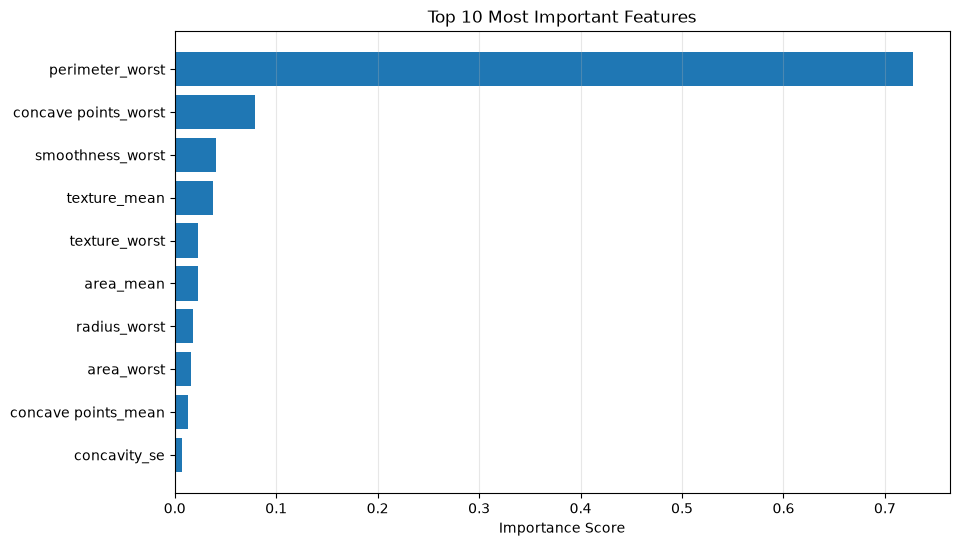

In [18]:
top = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.grid(axis="x",alpha=0.3)

plt.show()

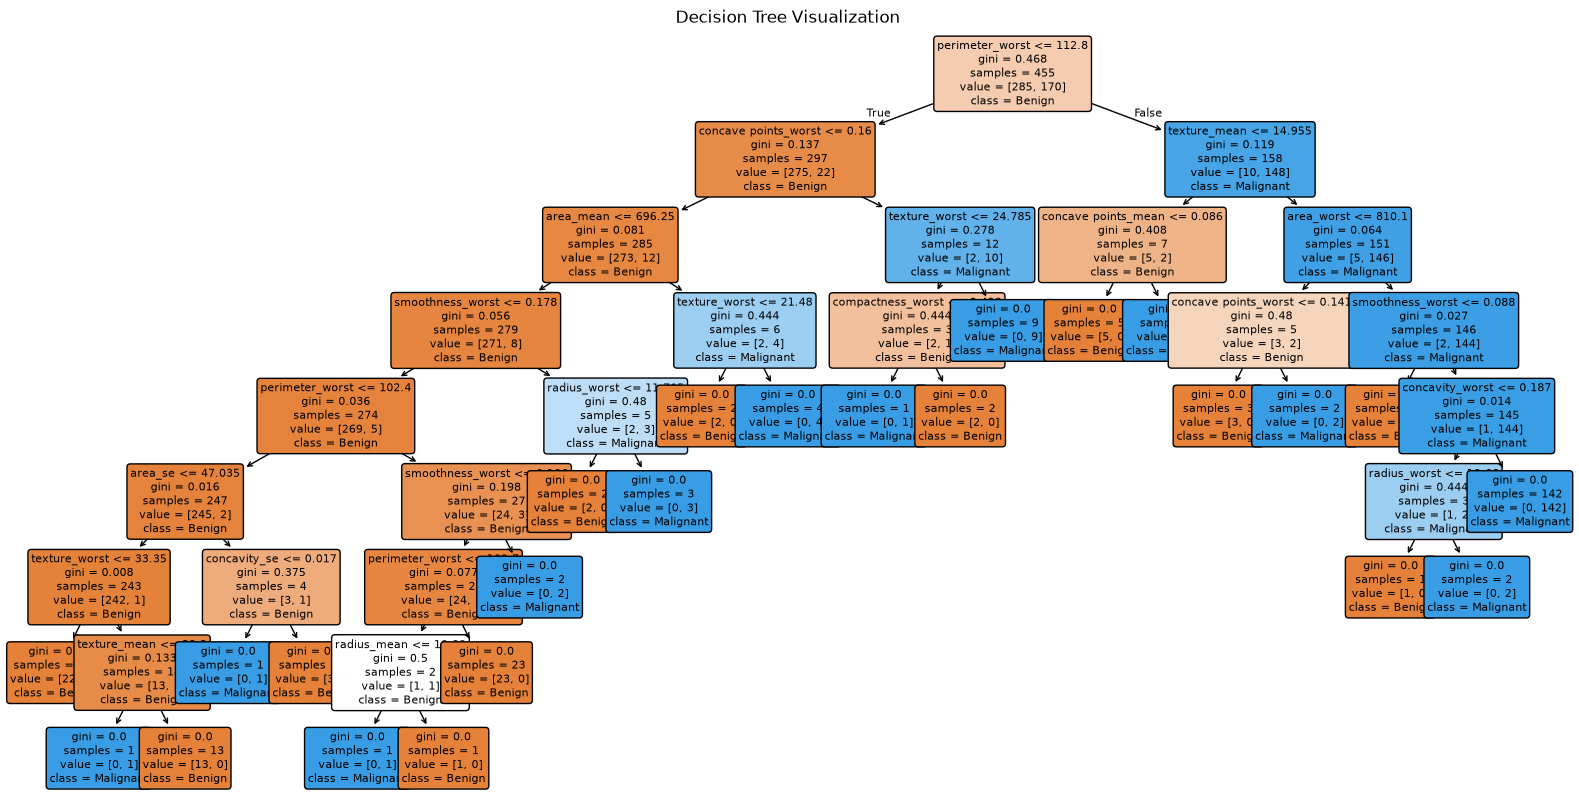

In [19]:
plt.figure(figsize=(20,10))

plot_tree(

    dt,

    feature_names=X.columns,

    class_names=["Benign","Malignant"],

    filled=True,

    rounded=True,

    fontsize=8

)

plt.title("Decision Tree Visualization")

plt.show()

In [20]:
new_patient = X.iloc[[25]]

prediction = dt.predict(new_patient)

probability = dt.predict_proba(new_patient)

print("="*50)

if prediction[0] == 1:
    print("Prediction : Malignant")
else:
    print("Prediction : Benign")

print("="*50)

print("Prediction Probabilities")

print(probability)

Prediction : Malignant
Prediction Probabilities
[[0. 1.]]


In [21]:
train_accuracy = dt.score(X_train,y_train)

test_accuracy = dt.score(X_test,y_test)

print("="*50)

print("Training Accuracy :",round(train_accuracy,4))

print("Testing Accuracy  :",round(test_accuracy,4))

print("="*50)

Training Accuracy : 1.0
Testing Accuracy  : 0.9298


# Hyperparameter Tuning + Overfitting Analysis + Pruning

In [23]:
results = []

for criterion in ["gini", "entropy"]:

    model = DecisionTreeClassifier(

        criterion=criterion,
        random_state=42

    )

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    results.append([criterion, train_acc, test_acc])

comparison = pd.DataFrame(

    results,

    columns=["Criterion",
             "Training Accuracy",
             "Testing Accuracy"]

)

comparison

,Criterion,Training Accuracy,Testing Accuracy
0,gini,1.0,0.929825
1,entropy,1.0,0.956140


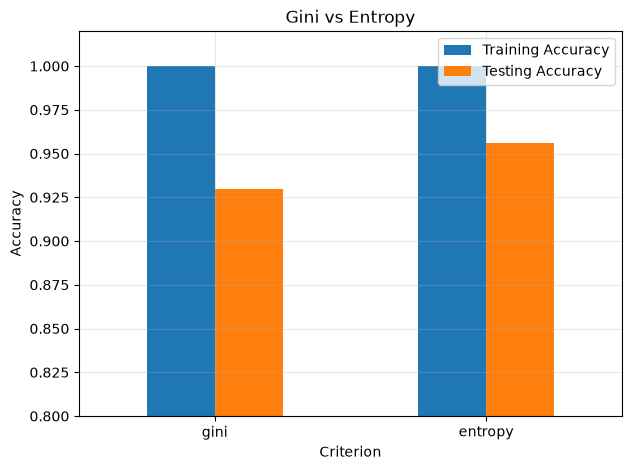

In [24]:
comparison.set_index("Criterion").plot(

    kind="bar",

    figsize=(7,5),

    rot=0

)

plt.title("Gini vs Entropy")

plt.ylabel("Accuracy")

plt.ylim(0.8,1.02)

plt.grid(alpha=0.3)

plt.show()

In [25]:
train_score = []
test_score = []

depths = range(1,21)

for depth in depths:

    model = DecisionTreeClassifier(

        max_depth=depth,

        random_state=42

    )

    model.fit(X_train,y_train)

    train_score.append(model.score(X_train,y_train))

    test_score.append(model.score(X_test,y_test))

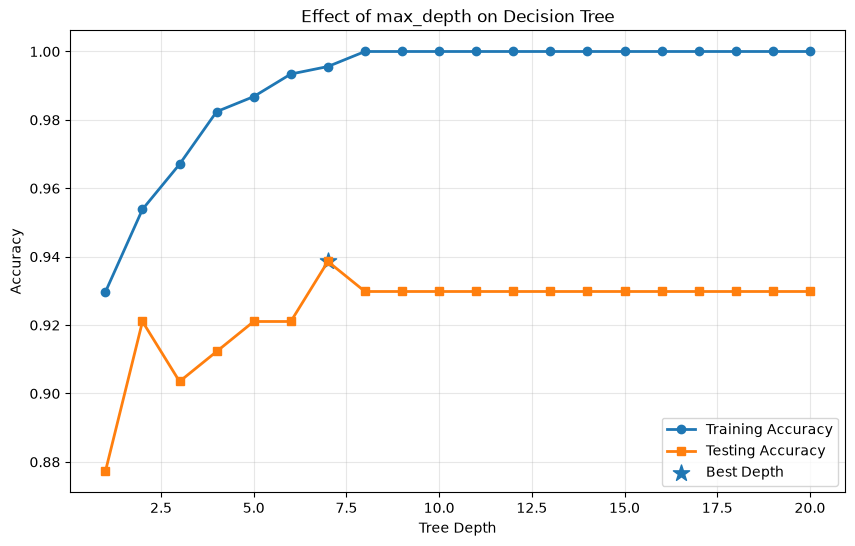

Best Depth : 7
Best Test Accuracy : 0.9386


In [26]:
plt.figure(figsize=(10,6))

plt.plot(

    depths,

    train_score,

    marker="o",

    linewidth=2,

    label="Training Accuracy"

)

plt.plot(

    depths,

    test_score,

    marker="s",

    linewidth=2,

    label="Testing Accuracy"

)

best_depth = depths[np.argmax(test_score)]

plt.scatter(

    best_depth,

    max(test_score),

    s=150,

    marker="*",

    label="Best Depth"

)

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Effect of max_depth on Decision Tree")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print("Best Depth :", best_depth)
print("Best Test Accuracy :", round(max(test_score),4))

In [27]:
split_values = range(2,21)

accuracy = []

for value in split_values:

    model = DecisionTreeClassifier(

        min_samples_split=value,

        random_state=42

    )

    model.fit(X_train,y_train)

    accuracy.append(model.score(X_test,y_test))

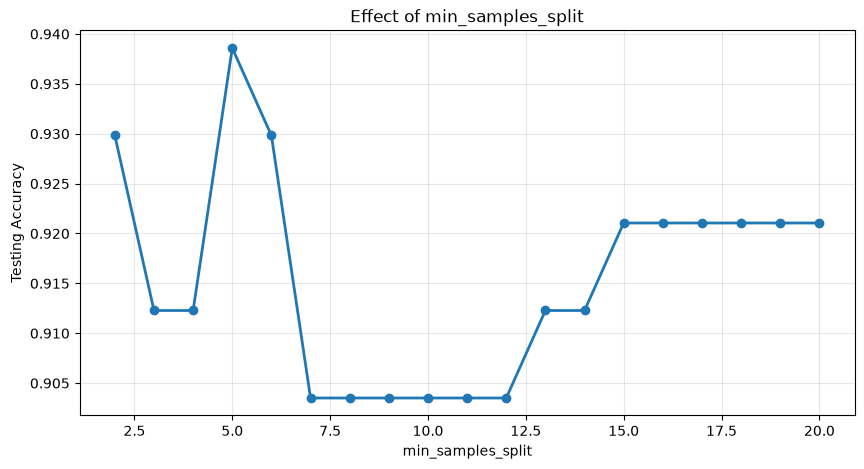

In [28]:
plt.figure(figsize=(10,5))

plt.plot(

    split_values,

    accuracy,

    marker="o",

    linewidth=2

)

plt.title("Effect of min_samples_split")

plt.xlabel("min_samples_split")

plt.ylabel("Testing Accuracy")

plt.grid(alpha=0.3)

plt.show()

In [29]:
leaf_values = range(1,16)

accuracy = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(

        min_samples_leaf=leaf,

        random_state=42

    )

    model.fit(X_train,y_train)

    accuracy.append(model.score(X_test,y_test))

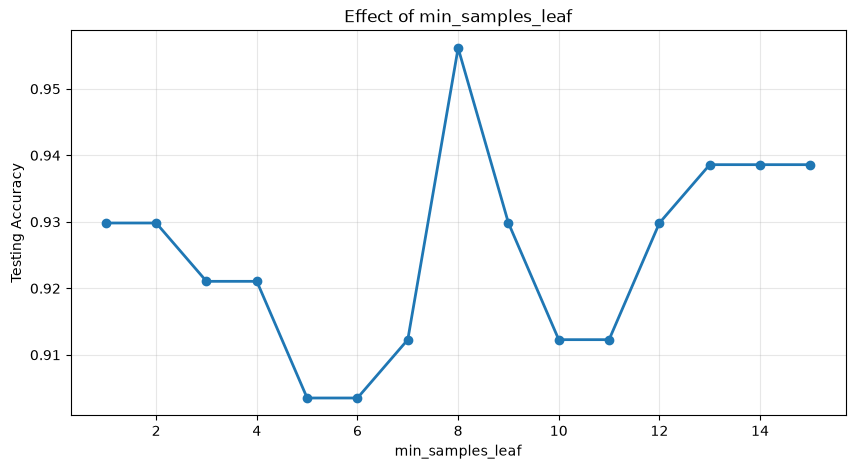

In [30]:
plt.figure(figsize=(10,5))

plt.plot(

    leaf_values,

    accuracy,

    marker="o",

    linewidth=2

)

plt.title("Effect of min_samples_leaf")

plt.xlabel("min_samples_leaf")

plt.ylabel("Testing Accuracy")

plt.grid(alpha=0.3)

plt.show()

In [31]:
leaf_nodes = range(2,31)

accuracy = []

for node in leaf_nodes:

    model = DecisionTreeClassifier(

        max_leaf_nodes=node,

        random_state=42

    )

    model.fit(X_train,y_train)

    accuracy.append(model.score(X_test,y_test))

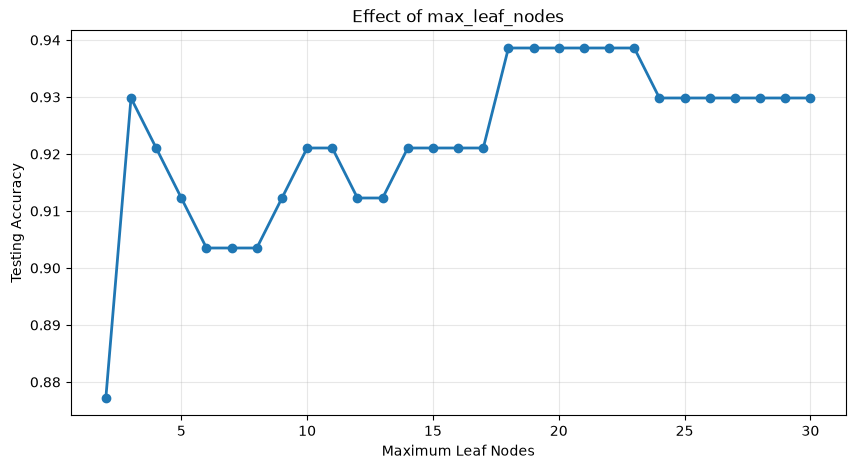

In [32]:
plt.figure(figsize=(10,5))

plt.plot(

    leaf_nodes,

    accuracy,

    marker="o",

    linewidth=2

)

plt.title("Effect of max_leaf_nodes")

plt.xlabel("Maximum Leaf Nodes")

plt.ylabel("Testing Accuracy")

plt.grid(alpha=0.3)

plt.show()

In [33]:
alphas = np.linspace(0,0.05,20)

train_acc = []
test_acc = []

for alpha in alphas:

    model = DecisionTreeClassifier(

        ccp_alpha=alpha,

        random_state=42

    )

    model.fit(X_train,y_train)

    train_acc.append(model.score(X_train,y_train))

    test_acc.append(model.score(X_test,y_test))

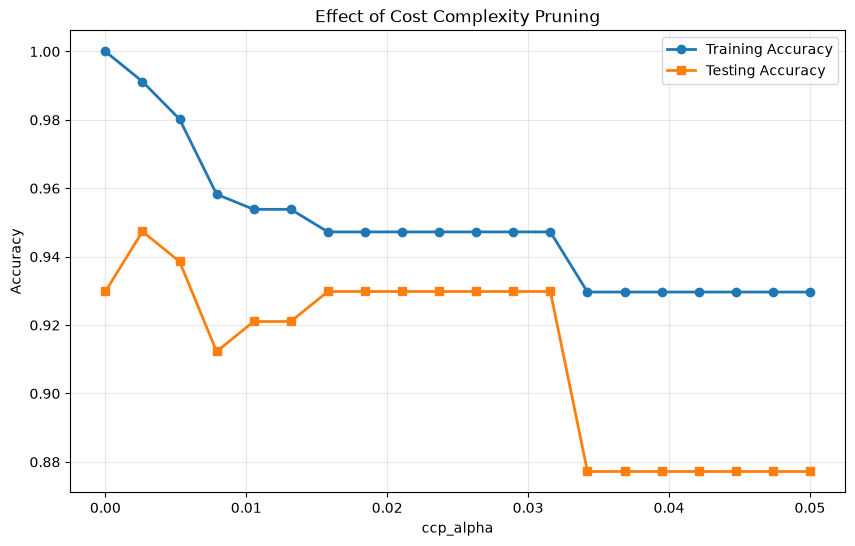

In [34]:
plt.figure(figsize=(10,6))

plt.plot(

    alphas,

    train_acc,

    marker="o",

    linewidth=2,

    label="Training Accuracy"

)

plt.plot(

    alphas,

    test_acc,

    marker="s",

    linewidth=2,

    label="Testing Accuracy"

)

plt.xlabel("ccp_alpha")

plt.ylabel("Accuracy")

plt.title("Effect of Cost Complexity Pruning")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [35]:
summary = pd.DataFrame({

    "Hyperparameter":[

        "Criterion",

        "max_depth",

        "min_samples_split",

        "min_samples_leaf",

        "max_leaf_nodes",

        "ccp_alpha"

    ],

    "Purpose":[

        "Choose Split Method",

        "Control Tree Height",

        "Minimum Samples Before Split",

        "Minimum Samples in Leaf",

        "Limit Number of Leaves",

        "Pruning"

    ]

})

summary

,Hyperparameter,Purpose
0,Criterion,Choose Split Method
1,max_depth,Control Tree Height
2,min_samples_split,Minimum Samples Before Split
3,min_samples_leaf,Minimum Samples in Leaf
4,max_leaf_nodes,Limit Number of Leaves
5,ccp_alpha,Pruning


In [36]:
deep_tree = DecisionTreeClassifier(

    random_state=42

)

deep_tree.fit(X_train,y_train)

small_tree = DecisionTreeClassifier(

    max_depth=3,

    random_state=42

)

small_tree.fit(X_train,y_train)

comparison = pd.DataFrame({

    "Model":[

        "Deep Tree",

        "Shallow Tree"

    ],

    "Training Accuracy":[

        deep_tree.score(X_train,y_train),

        small_tree.score(X_train,y_train)

    ],

    "Testing Accuracy":[

        deep_tree.score(X_test,y_test),

        small_tree.score(X_test,y_test)

    ]

})

comparison

,Model,Training Accuracy,Testing Accuracy
0,Deep Tree,1.000000,0.929825
1,Shallow Tree,0.967033,0.903509


# Regression Trees + Advanced Visualization + dtreeviz

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [39]:
housing = fetch_california_housing(as_frame=True)

X_reg = housing.data

y_reg = housing.target

print("Dataset Shape :", X_reg.shape)

X_reg.head()

Dataset Shape : (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [40]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(

    X_reg,

    y_reg,

    test_size=0.2,

    random_state=42

)

In [41]:
reg_tree = DecisionTreeRegressor(

    max_depth=6,

    random_state=42

)

reg_tree.fit(X_train_reg,y_train_reg)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [42]:
y_pred_reg = reg_tree.predict(X_test_reg)

In [45]:
mae = mean_absolute_error(y_test_reg,y_pred_reg)

mse = mean_squared_error(y_test_reg,y_pred_reg)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg,y_pred_reg)

print("="*50)

print("MAE  :",round(mae,4))

print("MSE  :",round(mse,4))

print("RMSE :",round(rmse,4))

print("R² Score :",round(r2,4))

print("="*50)

MAE  : 0.5008
MSE  : 0.4973
RMSE : 0.7052
R² Score : 0.6205


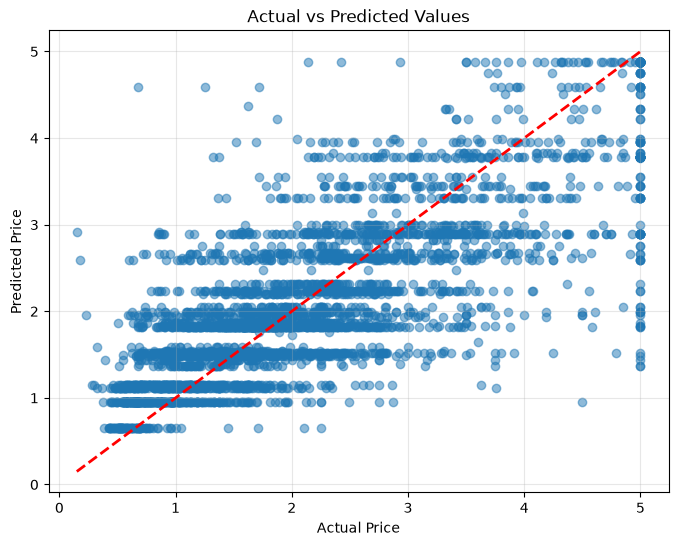

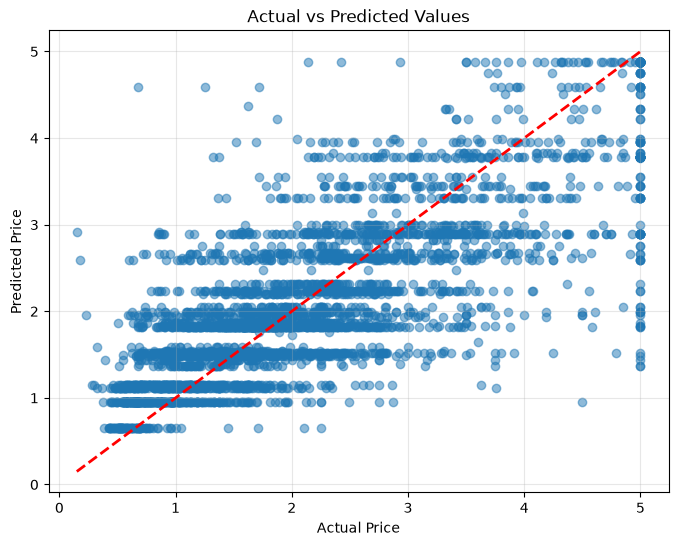

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test_reg,

    y_pred_reg,

    alpha=0.5

)

plt.plot(

    [y_test_reg.min(),y_test_reg.max()],

    [y_test_reg.min(),y_test_reg.max()],

    "r--",

    linewidth=2

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Values")

plt.grid(alpha=0.3)

plt.show()
plt.figure(figsize=(8,6))

plt.scatter(

    y_test_reg,

    y_pred_reg,

    alpha=0.5

)

plt.plot(

    [y_test_reg.min(),y_test_reg.max()],

    [y_test_reg.min(),y_test_reg.max()],

    "r--",

    linewidth=2

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Values")

plt.grid(alpha=0.3)

plt.show()

In [49]:
importance = pd.DataFrame({

    "Feature":X_reg.columns,

    "Importance":reg_tree.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
0,MedInc,0.729888
5,AveOccup,0.137787
1,HouseAge,0.043518
2,AveRooms,0.034038
6,Latitude,0.030302
7,Longitude,0.016880
4,Population,0.004349
3,AveBedrms,0.003238


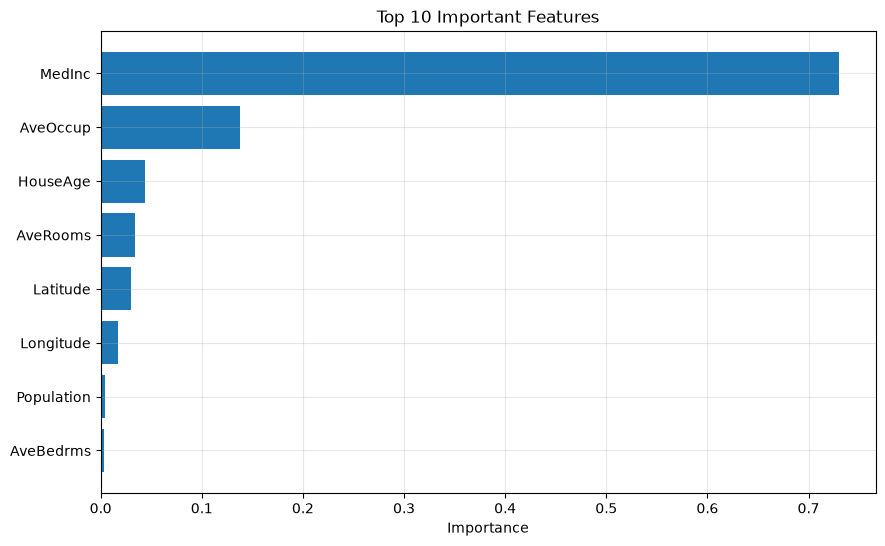

In [50]:
top = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.grid(alpha=0.3)

plt.show()

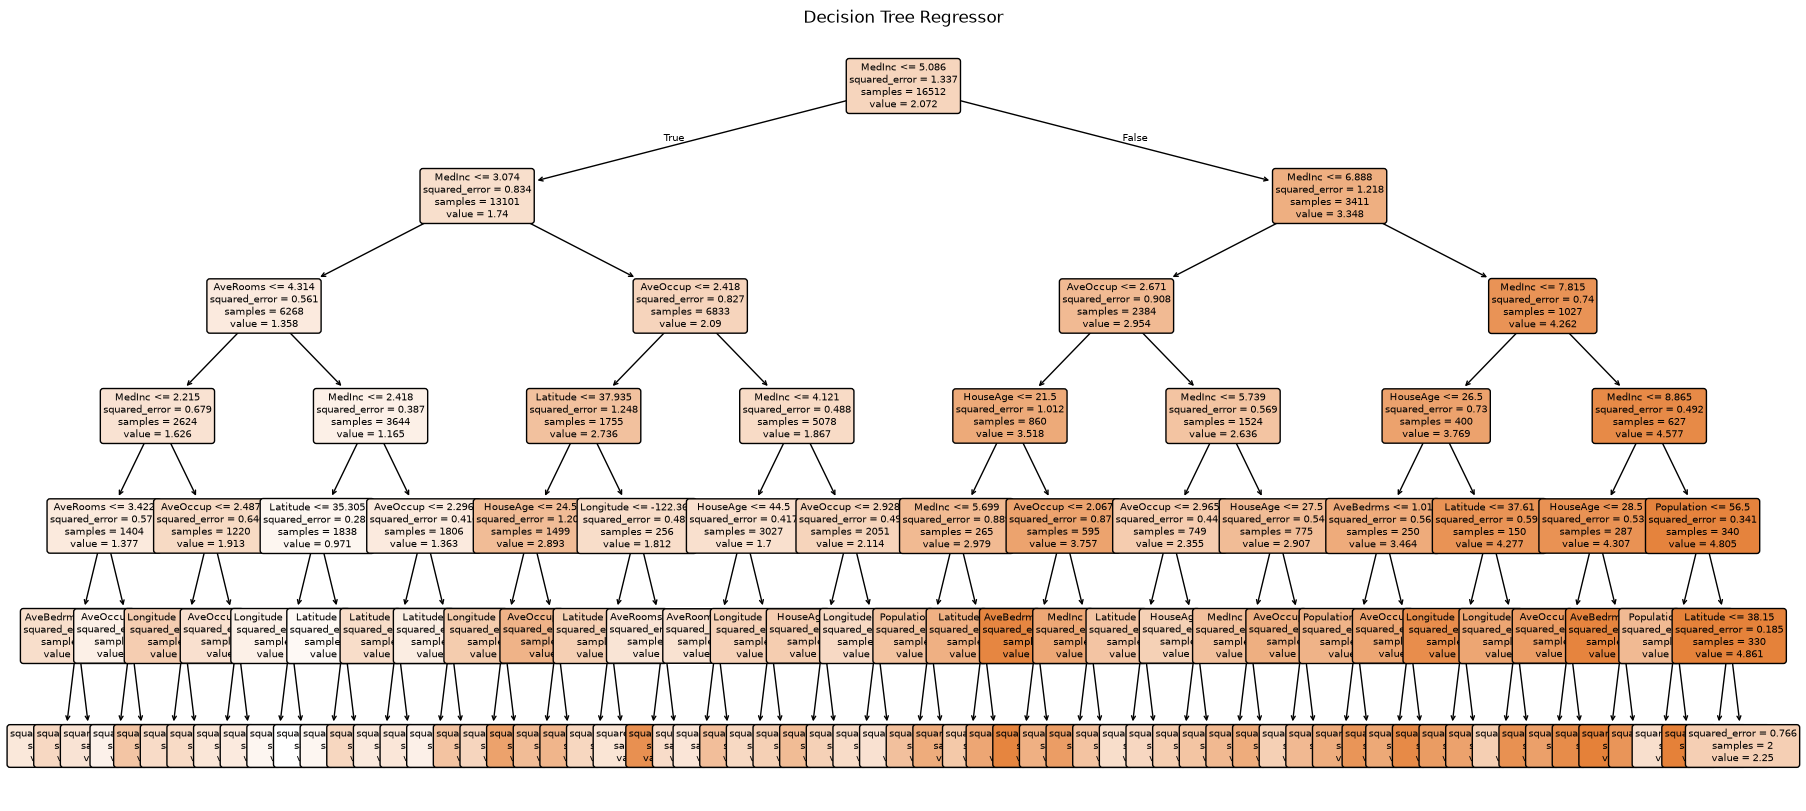

In [51]:
plt.figure(figsize=(22,10))

plot_tree(

    reg_tree,

    feature_names=X_reg.columns,

    filled=True,

    rounded=True,

    fontsize=7

)

plt.title("Decision Tree Regressor")

plt.show()

In [53]:
from dtreeviz import model

In [60]:
viz = model(

    reg_tree,

    X_train=X_train_reg,

    y_train=y_train_reg,

    feature_names=list(X_reg.columns),

    target_name="House Price"

)

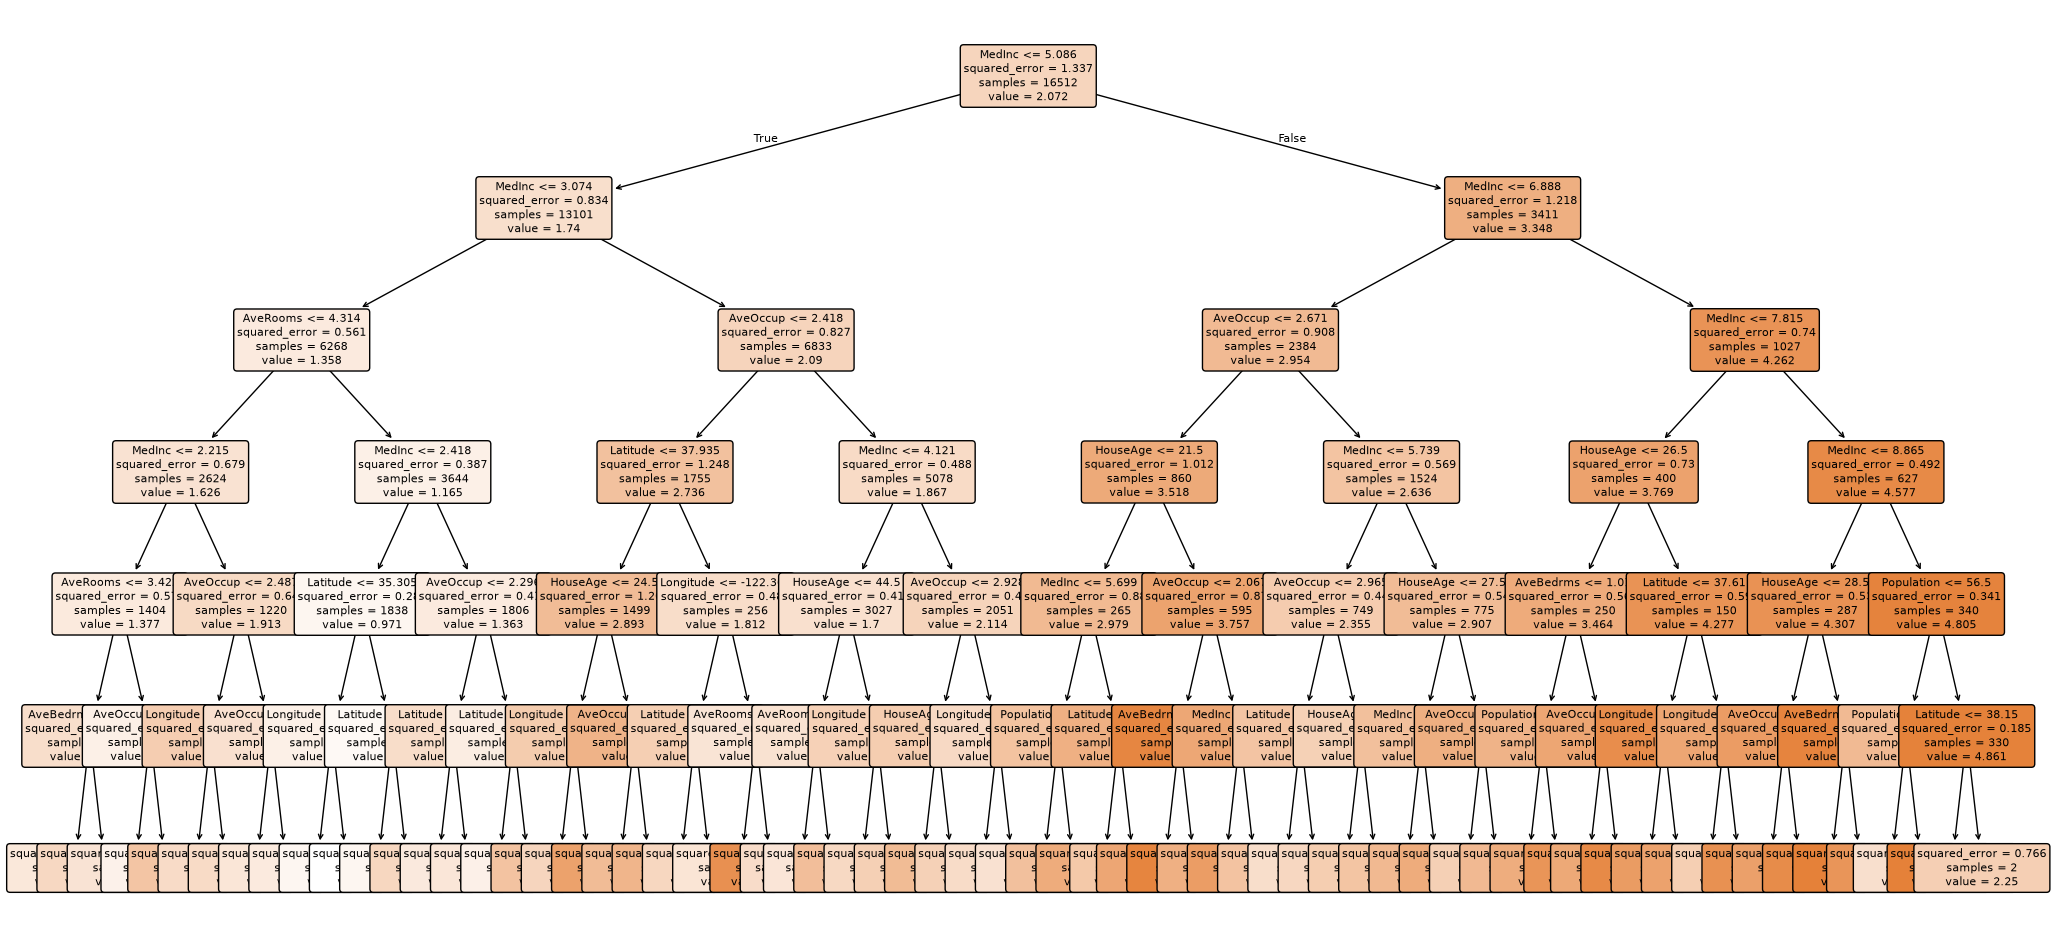

In [63]:
plt.figure(figsize=(25,12))

plot_tree(
    reg_tree,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()


In [62]:
comparison = pd.DataFrame({

    "Classification Tree":[

        "Predict Category",

        "Entropy/Gini",

        "Information Gain",

        "Class Label"

    ],

    "Regression Tree":[

        "Predict Numeric Value",

        "MSE",

        "Variance Reduction",

        "Mean Value"

    ]

})

comparison

,Classification Tree,Regression Tree
0,Predict Category,Predict Numeric Value
1,Entropy/Gini,MSE
2,Information Gain,Variance Reduction
3,Class Label,Mean Value
